# Joint-data HMM inference

The follwoing notebook infers a hidden Markov model from two different types of data in a joint manner. First, the arrival time of the HMM in the final state is fitted to resemble a given time to failure distribution. As a second step, the transition matrix that is yielded from this process is plugged into an inference algorithm and the emission probabilities are learned from real observations.

The structure of the HMM is motivated like this:

We assume that the degradation of a component (in this case wind turbine main bearing) is progresses monotonically along from one state to another. Once a particular degradation state is reached, the system can no longer jump into a healthier state. At most three possible transtions are allowed from any state:

- Stay in the same state
- Progress into the next degradation level
- Transition to failure state

It is reasonable to assume that the probability of transition to the failure state increases with higher degradation levels, so as we move from one state to the next, the probability of failure increases. 



In [1]:
from typing import Any
from pathlib import Path

from scipy.stats import Normal

import jax
from jax.random import key
import jax.numpy as jnp
from jax import Array

from plotting_functions import (
    plot_hmm_params, 
    plot_daily_time_series,
    plot_time_to_failure_distribution,
    plot_fit
    )


import matplotlib as mpl
import matplotlib.pyplot as plt

# Imports for the Baum Welch algorithm
from baum_welch_jax import HiddenMarkovParameters
from baum_welch_jax.util import wrapped_jit, normalize_rows
from baum_welch_jax.algorithms import baum_welch, generate_sequence
from baum_welch_jax.models import FreezeConfig, FreezeMasks

from load_data import load_daily_indicator_data

from optimization import fit_absorption_times


In [2]:
# Configure jax settings and plotting before running any code
jax.config.update("jax_enable_x64", True)
jnp.set_printoptions(precision=3)

mpl.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})


In [3]:
daily_time_series = load_daily_indicator_data(Path('indicator_data/lin_reg'))
print('Number of sequences:', len(daily_time_series))

residuals_14.csv excluded from training, r2 = 0.092 < 0.9
Number of sequences: 14


Time series are truncated to all have the same length, this is currently a limitation of the Baum Welch implementation.

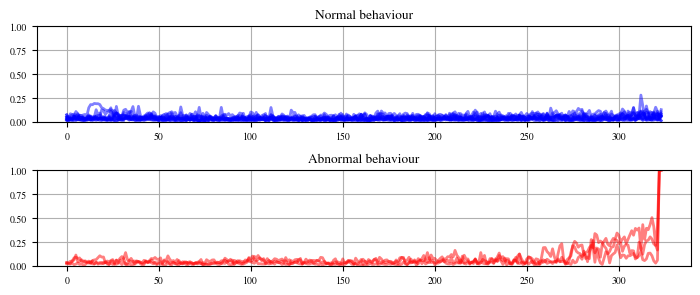

In [4]:
fig, ax = plot_daily_time_series(daily_time_series)
fig.set_size_inches(7, 3)
plt.tight_layout()
plt.show()


After choosing suitable bins, we construct the discrete observation sequences from which we will learn later on.

In [5]:
bins = jnp.linspace(0,.35, 8)

observation_sequences = jnp.digitize(daily_time_series, bins, right=True) - 1
observation_sequences = observation_sequences.at[daily_time_series > 0.99].set(8)


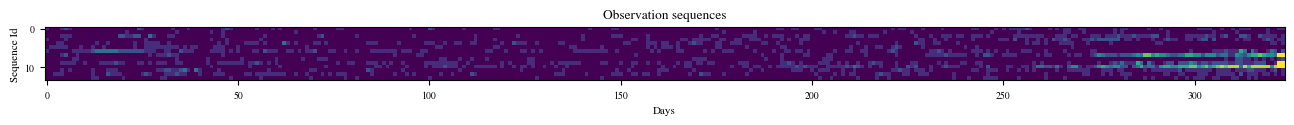

In [6]:

plt.gcf().set_size_inches(16, 4)
plt.imshow(observation_sequences)
plt.title('Observation sequences')
plt.xlabel('Days')
plt.ylabel('Sequence Id')
plt.show()

We now define the function which computes the probability of reaching the final state before step $t$ (i.e. the probability of failure before $t$). It is just the iterative application of a transition matrix to the initial state $s_0 = (1, 0, \dots, 0)$.

In [7]:
@wrapped_jit(static_argnames=['n_steps'])
def final_state_arrival_distribution(T: Array, n_steps: int = 100):

    n, _ = T.shape

    def step(state_distr: Array, _: Any) -> Array: 

        state_distr =  state_distr @ T

        return state_distr, state_distr[-1]
    
    state_distr, arrival_probabilities = jax.lax.scan(
        step,
        jnp.zeros(n).at[0].set(1.0),
        length=n_steps
    )

    return state_distr, arrival_probabilities

# Failure probabilities from NREL report (2023)


The report `Main Bearing Replacement and Damage − A Field Data Study on 15 Gigawatts of Wind Energy Capacity` presents a lognormal distribution for main bearing failure. However, they only report some numbers. In particular, they mention that 90% of main bearings survive until 10.5 years. They also state that the the survival rate for 20 years is 78%. Also, they claim that the best fit for their data was achieved by lognormal distribution. From this information we can calculate the parameters of the lognormal distribution.

So $S(10.5) = 0.9$ and $S(20) = 0.78$, where 
$$S(t) = 1 - \mathbb{P}(T < t) =1 - \Phi\left(\frac{\ln t - \mu}{\sigma}\right)$$

Let now $A = \Phi^{-1}(1 - 0.9)$ and $B = \Phi^{-1}(1 - 0.78)$, then

$$\frac{\ln 10.5 - \mu}{\sigma} = A \Rightarrow \ln 10.5 - \mu = \sigma A$$
and
$$\frac{\ln 20 - \mu}{\sigma} = B \Rightarrow \ln 20 - \mu = \sigma B$$

So, solving for $\mu$ and $\sigma$ yields
$$\sigma = \frac{\ln 10.5 - \ln 20}{ A - B}, ~~ \mu = \ln 10.5 - \sigma A $$

In [8]:
# Based on the NREL report

A = Normal().icdf(1 -  0.9)
B = Normal().icdf(1 - 0.78)

sigma = (jnp.log(10.5) - jnp.log(20)) / (A - B)
mu = jnp.log(10.5) - sigma * A

print('mu:', mu, 'sigma:', sigma)


mu: 3.972585041839995 sigma: 1.2650367166361958


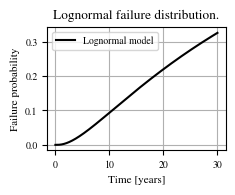

In [9]:
fig, ax = plot_time_to_failure_distribution(years=30, mu=mu, sigma=sigma)

plt.show()

It is also possible to reproduce their plot of the survival rate:

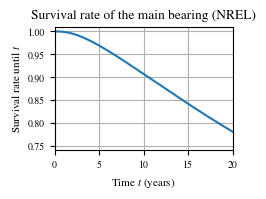

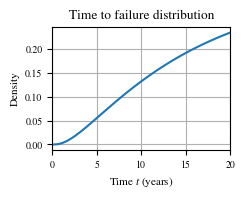

In [10]:
def survival_rate(t):
    return 1 - Normal(mu=mu, sigma=sigma).cdf(jnp.log(t))

def ttf_distribution(t):
    return Normal(mu=mu, sigma=sigma).pdf(jnp.log(t))

def sample_ttf(n):
    return jnp.exp(Normal(mu=mu, sigma=sigma).sample(n))

x_lim = 20
rates = survival_rate(jnp.linspace(0.01, x_lim, 500))
plt.plot(jnp.linspace(0.01, x_lim, 500), rates)
plt.xlim(0,x_lim)
plt.ylim(.74, 1.01)
plt.grid()
plt.ylabel('Survival rate until $t$')
plt.xlabel('Time $t$ (years)')
plt.title('Survival rate of the main bearing (NREL)')
plt.gcf().set_size_inches(2.3, 1.6)
plt.show()

plt.plot(jnp.linspace(0.01, x_lim, 500), ttf_distribution(jnp.linspace(0.01, x_lim, 500)))
plt.xlim(0,x_lim)
plt.grid()
plt.ylabel('Density')
plt.xlabel('Time $t$ (years)')
plt.title('Time to failure distribution')
plt.gcf().set_size_inches(2.3, 1.6)
plt.show()

## Fitting the HMM

Fitting the hidden Markov model $\{T, O, \mu \}$ procceeds in three stages.

- First, fit the transition matrix $T$ using a genetic algorithm to fit the prescribed CDF $F$.
- Then, adapt the observation probabilities $O$ such that the model correctly simulates healthy sequences.
- Use the sequences with failures a the end to fit certain blocks of $T$ and $O$, such that the simulations leading up to failure align with the data.
- Do a final genetic optimization on the upper left block of $T$ to restore the fit of the time to failure distribution (e.g. make the CDF the same as $F$ again)

In [11]:
# Define model parameters
n = 7 # Number of states
m = 9 # Number of observations

years = 30 # Time horizon for fitting the time to failure distribution

In [12]:

# Convert to days and formulate the objective function
n_days = years * 365
days = jnp.arange(1,n_days + 1)

# Calculate the true distribution to which we want to fit
cdf = jnp.array(Normal(mu=mu, sigma=sigma).cdf(jnp.log(days/365)))

def objective_function(arr: Array):
    _, _arrival = final_state_arrival_distribution(arr, 365 * years)
    return jnp.sum((_arrival - cdf) ** 2)


In [13]:
n_params = n-1

def construct_transition_matrix(parameters: Array) -> Array:
    # Construct a transition matrix from a parameter vector.
    # The first band above the diagonal is an non decreasing sequence of transition probabilities
    upper = parameters.cumsum()

    # Each row of the matrix must sum to 1!
    return (
        jnp.eye(len(parameters) + 1) 
        - jnp.diag(jnp.array([*upper, 0.0])) 
        + jnp.diag(upper, k=1) 
    )


best_parameters, population, score_history = fit_absorption_times(n_params, objective_function, construct_transition_matrix)

Current best score = 0.02009: 100%|██████████| 5/5 [00:12<00:00,  2.44s/it]


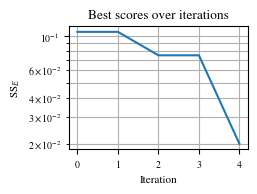

In [14]:
plt.semilogy(score_history)
plt.title('Best scores over iterations')
plt.xlabel('Iteration')
plt.ylabel('$\\text{SS}_E$')
plt.grid(which='both')
plt.gcf().set_size_inches(2.3, 1.6)
plt.show()


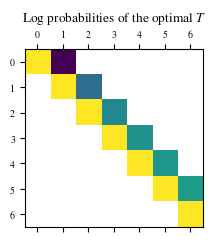

In [15]:
plt.matshow(jnp.log(best_parameters))
plt.gcf().set_size_inches(2.3, 2.3)
plt.title('Log probabilities of the optimal $T$')
plt.show() 

best_matrices = jax.vmap(construct_transition_matrix)(population[:100])
mean_matrix = jnp.mean(best_matrices, axis=0)
std_matrix = jnp.std(best_matrices, axis=0)


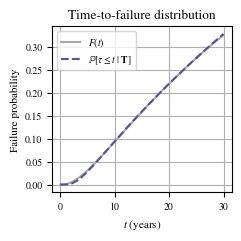

In [16]:
plot_fit(best_parameters, final_state_arrival_distribution)
plt.show()

Indices of failure sequences:	 [ 7  9 10]
Indices of healthy sequences:	 [ 0  1  2  3  4  5  6  8 11 12 13]
Indices of noisy sequences:	 [ 2  4  6  7  9 10 11]


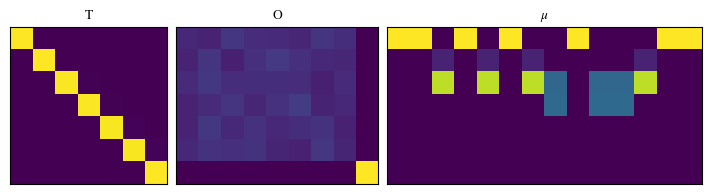

In [17]:
# For the fit of the observation sequences, we use a maximum likelihood method.plt
# The Baum Welch algorithm is an Expectation-Maximization variant and we just use
# its simplest form, with discrete hidden states and discrete emissions.
# Fitting is performed separtely for the healthy and faulty sequences, in a two step way.

# We start by dividing the sequences into bins
failure_indices = jnp.arange(len(observation_sequences))[jnp.any(observation_sequences == m-1, axis=-1)]
print('Indices of failure sequences:\t', failure_indices)

healthy_indices = jnp.array([k for k in range(len(observation_sequences)) if k not in failure_indices]).astype(jnp.int32)
print('Indices of healthy sequences:\t', healthy_indices)

# Some sequences are more noisy than other sequences, 
# so we assume they already start in a more advanced hidden state
noisy_sequences = jnp.arange(len(observation_sequences))[jnp.any(observation_sequences >= 3, axis=-1)]
print('Indices of noisy sequences:\t', noisy_sequences)


# Now we assemble our initial state distributions for all sequences...
initial_state_distributions = jnp.array([
    [1.0] + [0.0] * (n - 1)
] * len(observation_sequences))

for idx in noisy_sequences:
    initial_state_distributions = initial_state_distributions.at[idx].set(jnp.array([0.0, 0.1, 0.9, 0.0] + [0.0] * (n - 4)))

for idx in failure_indices:
    initial_state_distributions = initial_state_distributions.at[idx].set(jnp.array([0.0, 0.0, 0.33, 0.34] + [0.0] * (n - 4)))

# ...and also prepare the initial guess for the observation probabilities
O_guess = jax.random.uniform(key(0), (n, m), minval=0.5, maxval=1.0)
O_guess = (
    O_guess.at[:-1, -1].set(0.0)
    .at[-1, :-1].set(0.0)
    .at[-1, -1].set(1.0)
)
O_guess = O_guess / jnp.sum(O_guess, axis=-1, keepdims=True)

# The guesses are combined with the previously determined transition matrix
hmm_init_guess = HiddenMarkovParameters(
    best_parameters, 
    jnp.array(O_guess), 
    jnp.array(initial_state_distributions))


fig, ax = plot_hmm_params(hmm_init_guess)
fig.set_size_inches(7, 3)
plt.show()


In [18]:
# It is time for optimization, we first show what a joint fit of the entire O and mu looks like
obs = jnp.array(observation_sequences)

# T is not allowed to change!
result = baum_welch(obs, hmm_init_guess, 1000, mode='log', tol=1e-6, freeze_config=FreezeConfig(T=True))

fitted_hmm = result.params.to_prob()

print('Number of iterations:', result.iterations)

Number of iterations: 35


Full fit of O and mu on all data jointly:


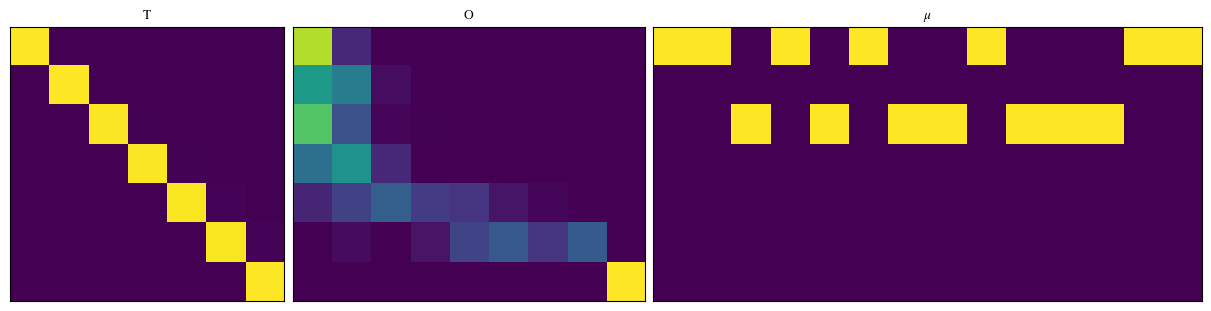

In [19]:
print('Full fit of O and mu on all data jointly:')
fig, ax = plot_hmm_params(fitted_hmm)
fig.set_size_inches(12, 6)
plt.show()

In [20]:
# Now, we split the paramters into two sections, the upper and lower blocks
split_row = 3


Before optimization:


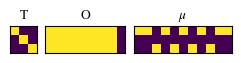

After optimization:


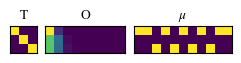

Full HMM after partial fit of O:


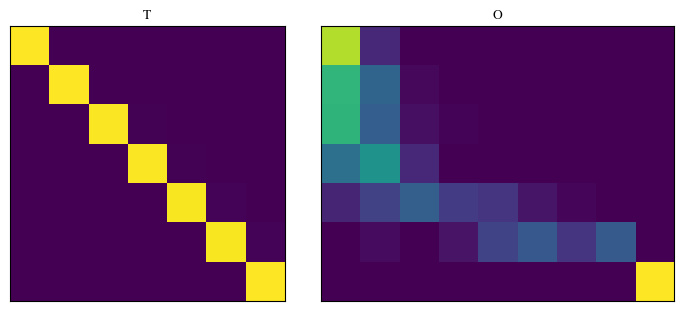

In [21]:
# The upper portion is trained only on the healthy sequences
training_sequences_healthy = observation_sequences[healthy_indices]

# We take the initial state probabilities from the previous fit
mu_init_healthy = fitted_hmm.mu[healthy_indices, :split_row]

# This step only fits a reduced process, considering only an upper left block of T..
healthy_T = fitted_hmm.T[:split_row,:split_row]

# ...and the first few rows of O
healhty_O = jnp.ones((split_row,m)).at[:, -1].set(0.0)#jax.random.uniform(jax.random.key(5), (split_row,m)).at[:, -1].set(0.0)
healthy_O = normalize_rows(healhty_O)

# We again contruct a paramters set
healthy_hmm_init = HiddenMarkovParameters(healthy_T, healthy_O, mu_init_healthy)

print('Before optimization:')
plot_hmm_params(healthy_hmm_init)
plt.show()

# Again, T is frozen
truncated_healthy = baum_welch(training_sequences_healthy, healthy_hmm_init, freeze_config=FreezeConfig(T=True))
healthy_hmm = truncated_healthy.params.to_prob()

print('After optimization:')
plot_hmm_params(healthy_hmm)
plt.show()

# We now re assemble the updated O matrix
partial_O = (
    fitted_hmm.O
    .at[:split_row]
    .set(healthy_hmm.O)
)
partial_hmm = HiddenMarkovParameters(fitted_hmm.T, partial_O, fitted_hmm.mu)

print('Full HMM after partial fit of O:')
fig, ax = plot_hmm_params(partial_hmm, plot_mu=False)
fig.set_size_inches(7, 3)
plt.show()


The difference might not be noticable at first, but the distribution of the observations has shifted significantly. Now we fit to the failure sequences.

Before optimization:


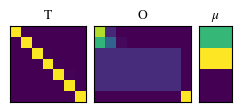

After optimization:


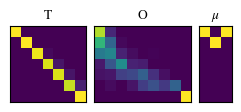

Full HMM after partial fit of T and O:


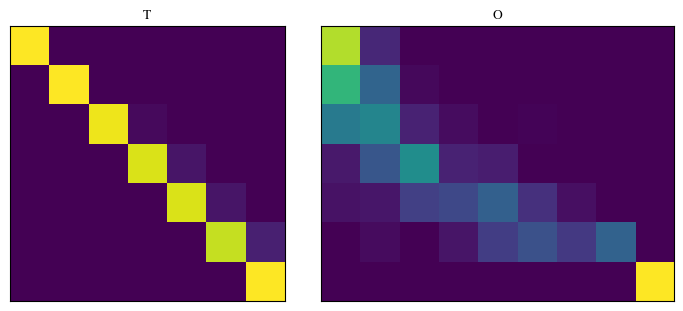

In [22]:
split_row_failure = 2
failure_sequences = observation_sequences[failure_indices]

# Since we have changed the process in the previous step, we again learn new initial state
# probabilities for the failure sequences.
mu_init = jnp.array([[0.2,0.2, 0.3, 0.3, 0.] + [0.0] * (n - 5)] * len(failure_indices))

# We allow for the lower part of T to be modified in this step, and we also allow 
# changes in O. Note that not all rows of O which were modified in the last step are
# kept fixed here. Actually one more row of O than of T is changeable!
masks = FreezeMasks(
    T=jnp.full((n,n), True, jnp.bool).at[split_row_failure:].set(False), # Only the part of T below the split_row can change
    O=jnp.full((n, m), True).at[split_row_failure:].set(False), # We allow changes in O 'further up' than in T
    mu=jnp.full_like(mu_init, False) # We also freshly learn the initial state probabilities for the failure sequences
)

# We initialize O completely uniformly on the rows where it is allowed to change (except the final column, which is 0)
O_init = normalize_rows(partial_hmm.O.at[split_row_failure:-1, :-1].set(1.0))

failure_hmm_init = HiddenMarkovParameters(partial_hmm.T, O_init, mu_init)

print('Before optimization:')
plot_hmm_params(failure_hmm_init)
plt.show()

failure_fit_result = baum_welch(failure_sequences, failure_hmm_init, freeze_config=masks)
failure_fitted_hmm = failure_fit_result.params.to_prob()

print('After optimization:')
plot_hmm_params(failure_fitted_hmm)
plt.show()

combined_hmm = HiddenMarkovParameters(failure_fitted_hmm.T, failure_fitted_hmm.O, initial_state_distributions)

print('Full HMM after partial fit of T and O:')
fig, ax = plot_hmm_params(combined_hmm, plot_mu=False)
fig.set_size_inches(7, 3)
plt.show()



Notice how now also the lower right block of $T$ has changed. The observation matrix now exhibits a clear evolution towards higher emissions. This aligns with our expected behavior. Because of the change in the degradation dynamics, we will however need to correct for this mismatch.

Note that the likelihood of this two step fit is lower then before, and after all these steps, the adherence to $F$ is no longer any good:

Likelihood fitted: -2962.167045382056
Likelihood combined: -3389.109954907081


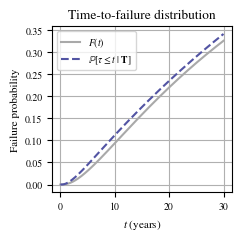

In [23]:
from baum_welch_jax.algorithms import log_likelihood


print('Likelihood fitted:', jnp.sum(log_likelihood(observation_sequences, fitted_hmm)))
print('Likelihood combined:', jnp.sum(log_likelihood(observation_sequences, combined_hmm)))

plot_fit(combined_hmm.T, final_state_arrival_distribution)
plt.show()

Here you can see what actually changed when compared to the fit of $O$ using the entire data at once.

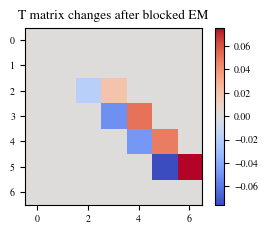

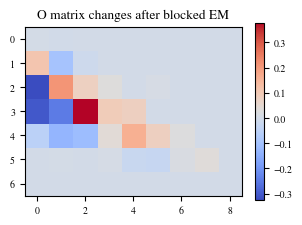

In [24]:
plt.gcf().set_size_inches(3.5, 2.3)
plt.imshow(combined_hmm.T - fitted_hmm.T, cmap='coolwarm')
plt.colorbar()
plt.title('T matrix changes after blocked EM')
plt.show()

plt.gcf().set_size_inches(3.5, 2.3)
plt.imshow(combined_hmm.O - fitted_hmm.O, cmap='coolwarm')
plt.colorbar()
plt.title('O matrix changes after blocked EM')
plt.show()

In [25]:
n_params = 2

def construct_transition_matrix_from_block(block_parameters: Array, full_T: Array = combined_hmm.T) -> Array:
    a, b = block_parameters
    return full_T.at[:2, :3].set(
        jnp.array(
            [[1.0 - a,  a,      0      ],
             [0.0,        1.0 -  b,     b]]
        )
    )

best_parameters_second_pass, population, score_history = fit_absorption_times(
    n_params, 
    objective_function, 
    construct_transition_matrix_from_block,
    n_generations=25,
    n_population=1000,
    n_survivors=100,
    n_best=200
    )


Current best score = Inf:   0%|          | 0/25 [00:00<?, ?it/s]

Current best score = 0.08801: 100%|██████████| 25/25 [00:04<00:00,  5.76it/s]


Before second optimization 2.4586171034716013


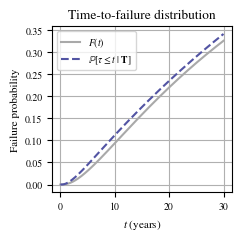

After second optimization 0.08801214412850705


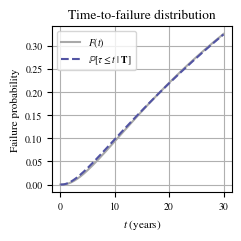

In [26]:
print('Before second optimization', objective_function(combined_hmm.T))
plot_fit(combined_hmm.T, final_state_arrival_distribution)
plt.show()
print('After second optimization', objective_function(best_parameters_second_pass))
plot_fit(best_parameters_second_pass, final_state_arrival_distribution)
plt.show()



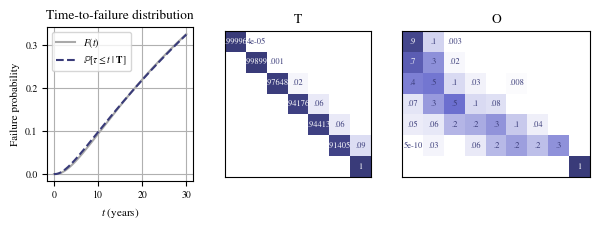

In [27]:
from matplotlib.colors import LinearSegmentedColormap


fig, ax = plt.subplots(figsize=(7,2), ncols=3, width_ratios=(n, n , m))
_, _ =plot_fit(
    best_parameters_second_pass, 
    final_state_arrival_distribution, 
    ax[0], 
    color_truth='darkgrey', 
    color_fitted=plt.cm.tab20b.colors[0])

mu_init = jnp.zeros(n).at[0].set(1.0)
final_hmm = HiddenMarkovParameters(
    best_parameters_second_pass,
    combined_hmm.O,
    mu_init
)

colors_seq =  ['white',
     plt.cm.tab20b.colors[3],
     plt.cm.tab20b.colors[2],
     plt.cm.tab20b.colors[1], 
     plt.cm.tab20b.colors[0]
     ]

cmap1 = LinearSegmentedColormap.from_list(
    "mycmap", 
    colors_seq
    )

_, _ = plot_hmm_params(final_hmm, plot_mu=False, with_numbers=True,ax = ax[1:], cmap=cmap1)#'PuBu')
plt.savefig("plots/combined_final_fit.pdf", bbox_inches='tight')
plt.show()


Number of usable failure samples: 2080


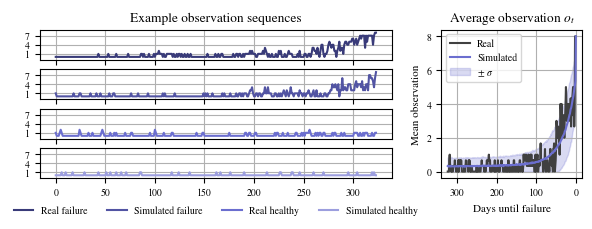

In [ ]:
from cycler import cycler
import numpy as np
import itertools

cmap = plt.cm.tab20b
color_cycle = itertools.cycle(cmap.colors)
plt.rcParams["axes.prop_cycle"] = cycler(color=cmap.colors)

n_simulations = 50
start_state = 0

def darken_color(color, factor=0.5):
    """Darken a Matplotlib color by a given factor (0 < factor < 1)."""
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

mu_init = jnp.zeros(n).at[start_state].set(1.0)


generation_hmm = HiddenMarkovParameters(
    best_parameters_second_pass,
    combined_hmm.O,
    mu_init
)

mosaic = [
    ['A', 'E'],
    ['B', 'E'],
    ['C', 'E'],
    ['D', 'E']
]

fig, ax = plt.subplot_mosaic(
    mosaic,
    figsize=(7, 1.75),  # total width 7 inches, height = arbitrary
    constrained_layout=False,
    gridspec_kw={'width_ratios': [5, 2]}
)

fig.subplots_adjust(
    top=0.95,   # top margin
    bottom=0.1, # bottom margin
    hspace=0.3   # vertical space between rows
)

handles_dict = {}

# Plot some example sequences

label = 'Real failure'
seq = observation_sequences[failure_indices[2]]
color=next(color_cycle)
handles_dict[label] = ax['A'].plot(jnp.arange(len(seq)), seq, color=color)
ax['A'].set_ylim(-1, 9)


label = 'Simulated failure'
seed = 25
states, observations = generate_sequence(key=key(seed), hmm=generation_hmm, length=324*20)
end = jnp.argmax(states) + 1
color=next(color_cycle)
start = max(end - 324, 0)
observations = observations[start:end]
states = states[start:end]
handles_dict[label] = ax['B'].plot(jnp.arange(len(observations)), observations, color=color)
ax['B'].set_ylim(-1, 9)



label = 'Real healthy'
seq = observation_sequences[0]
color=next(color_cycle)
handles_dict[label] = ax['C'].plot(jnp.arange(len(seq)), seq, color=color)
ax['C'].set_ylim(-1, 9)


label = 'Simulated healthy'
seed = 11
states, observations = generate_sequence(key=key(seed), hmm=generation_hmm, length=324*20)
end = jnp.argmax(states) + 1
color=next(color_cycle)
end = max(324, end)
start = max(end - 324, 0)
observations = observations[start:end]
states = states[start:end]
handles_dict[label] = ax['D'].plot(jnp.arange(len(observations)), observations, color=color)#, label=label, alpha=0.5, s=markersize)
ax['D'].set_ylim(-1, 9)



for k, _ax in enumerate(['A', 'B', 'C', 'D']):
    ax[_ax].grid()
    ax[_ax].set_yticks(range(1,9, 3))
    if k != 3:
        ax[_ax].set_xticks([0, 50, 100, 150, 200, 250, 300], [''] * 7)

# Add title and legend
ax['A'].set_title('Example observation sequences')
ax['D'].legend(
    handles=[val.pop() for val in handles_dict.values()],
    labels=handles_dict.keys(),
    loc='lower center',
    ncol=len(handles_dict),      # multiple columns if needed
    bbox_to_anchor=(0.5, -1.5), # below the axes
    frameon=False
)


# Plot the statistics of observations

n_simulations = 11_000
start_state = 0
seq_len = 324

states, observations = jax.vmap(lambda _k: generate_sequence(key=key(_k), hmm=generation_hmm, length=324*20))(jnp.arange(n_simulations))

observations = observations[jnp.max(states, axis=-1) >= n-1]
states = states[jnp.max(states, axis=-1) >= n-1]
end_indices = jnp.argmax(states, axis=-1)

relevant_obs = observations[end_indices >= seq_len]
end_indices = end_indices[end_indices >= seq_len]

print('Number of usable failure samples:', len(end_indices))
simulated_obs_seq = jnp.array([relevant_obs[j, idx-seq_len:idx + 1] for j, idx in enumerate(end_indices)])

mean_simulated_obs = simulated_obs_seq.mean(axis=0)
std_simulated_obs = simulated_obs_seq.std(axis=0)
mean_real_obs = failure_sequences.mean(axis=0)
std_real_obs = failure_sequences.std(axis=0)



ax['E'].plot(mean_real_obs, color=darken_color('white', factor=0.25), label='Real')
ax['E'].plot(mean_simulated_obs, color=cmap.colors[2], label='Simulated')
ax['E'].fill_between(
    jnp.arange(len(mean_simulated_obs)), 
    mean_simulated_obs + std_simulated_obs, 
    jnp.clip(mean_simulated_obs - std_simulated_obs, 0),  
    color=cmap.colors[2], 
    alpha=0.25,
    label='$\\pm ~ \\sigma$')
ax['E'].set_xticks(324 - jnp.array([300, 200, 100, 0]), jnp.array([300, 200, 100, 0]))
ax['E'].set_title('Average observation $o_t$')
ax['E'].set_xlabel('Days until failure')
ax['E'].set_ylabel('Mean observation')
ax['E'].grid()
ax['E'].legend()

plt.savefig("plots/output_analysis.pdf", bbox_inches='tight')
plt.show()



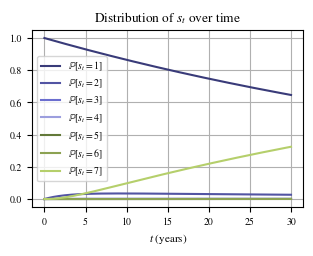

In [29]:
len_days = 30 * 365

mu = jnp.array([1.0] + [0.0] * (n -1))

def step(carry, _):
    distr = carry @ generation_hmm.T

    return distr, distr

_, distr_seq = jax.lax.scan(step,
             mu,
             length=len_days)


distr_seq.shape

for _state in range(0,n):
    plt.plot(np.arange(len_days) / 365, distr_seq[:, _state], label=f'$\\mathbb{{P}}[s_t = {_state + 1}]$')

plt.gcf().set_size_inches(3.5, 2.3)
plt.title('Distribution of $s_t$ over time')
plt.grid()
plt.xlabel('$t$ (years)')
plt.legend()
plt.show()

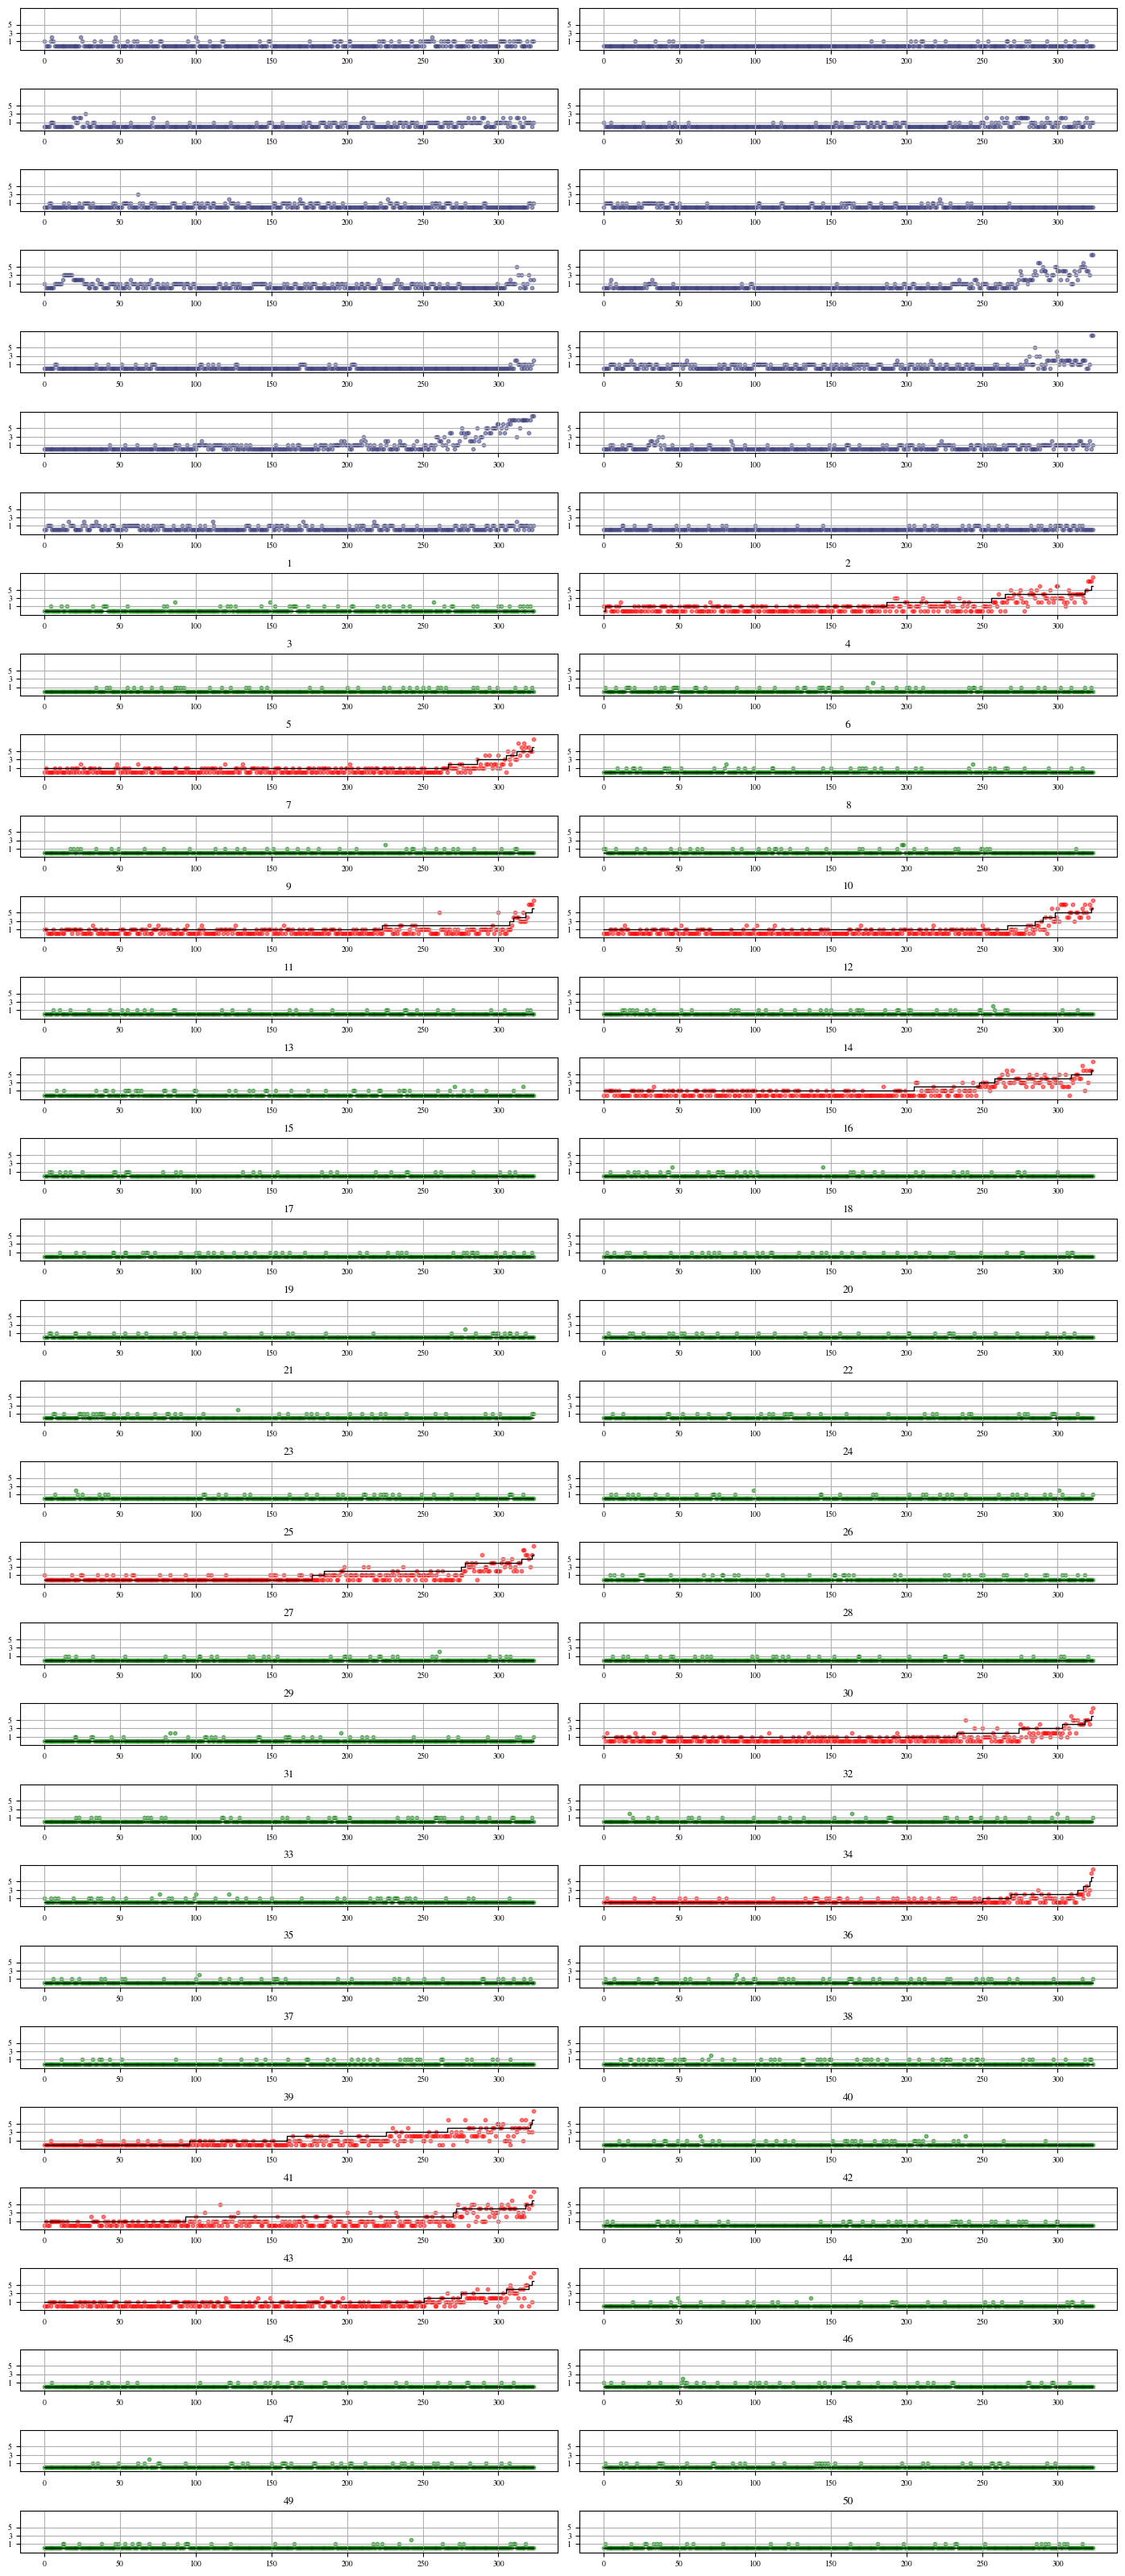

In [30]:
# Plots of many sequences to compare visually

n_simulations = 50
start_state = 0

mu_init = jnp.zeros(n).at[start_state].set(1.0)

generation_hmm = HiddenMarkovParameters(
    best_parameters_second_pass,
    combined_hmm.O,
    mu_init
)


nrows = (len(observation_sequences) + n_simulations) // 2

fig, ax = plt.subplots(nrows, 2)
fig.set_size_inches(14, nrows)

for k, seq in enumerate(observation_sequences):
    coord = k // 2, k % 2
    ax[*coord].scatter(jnp.arange(len(seq)), seq, alpha=0.5, s=10)
    ax[*coord].set_ylim(-1, 9)

for j in range(1, n_simulations + 1):
    states, observations = generate_sequence(key=key(j), hmm=generation_hmm, length=324*20)
    end = jnp.argmax(states) + 1

    if end <= 1 or jnp.max(states) < n-1:
        color = 'green'
    else:
        color = 'red'
    
    if end < 324:
        end = 324

    start = max(end - 324, 0)
    observations = observations[start:end]
    states = states[start:end]
    coord = (k + j) // 2, (k + j) % 2
    ax[*coord].set_title(str(j))
    ax[*coord].scatter(jnp.arange(len(observations)), observations, alpha=0.5, color=color, s=10)
    ax[*coord].step(jnp.arange(len(observations)), states, 'k', linewidth=1.0)
    ax[*coord].set_ylim(-1, 9)

for row in ax:
    for _ax in row:
        _ax.grid()
        _ax.set_yticks(range(1,7, 2))
plt.tight_layout()
plt.show()



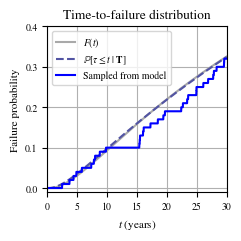

In [31]:
_states, _ = generate_sequence(key(3), generation_hmm.replace_mu(jnp.array(100*[[1.0] + [0.0] * (n -1)])), length=365 * 30)
plot_fit(generation_hmm.T, final_state_arrival_distribution)

plt.plot(jnp.linspace(0, 30, len(_states[0])), (_states == jnp.max(_states)).mean(axis=0), color='blue', label='Sampled from model')
plt.legend()
plt.xlim(0,30)
plt.ylim(-0.01, 0.4)
plt.show()